In [147]:
import MetaTrader5 as mt5
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

In [148]:
if not mt5.initialize():
    print("Initialize failed")
    quit()

In [149]:
# request connection status and parameters
print(mt5.terminal_info())
# get data on MetaTrader 5 version
print(mt5.version())

TerminalInfo(community_account=True, community_connection=True, connected=True, dlls_allowed=False, trade_allowed=False, tradeapi_disabled=False, email_enabled=False, ftp_enabled=False, notifications_enabled=True, mqid=True, build=5660, maxbars=100000000, codepage=0, ping_last=46643, community_balance=0.0, retransmission=0.45575811471765226, company='RoboForex Ltd', name='RoboForex MT5 Terminal', language='English', path='C:\\Program Files\\RoboForex MT5 Terminal', data_path='C:\\Program Files\\RoboForex MT5 Terminal', commondata_path='C:\\Users\\artem\\AppData\\Roaming\\MetaQuotes\\Terminal\\Common')
(500, 5660, '27 Feb 2026')


In [150]:
symbol = "XAUUSD"
# Define period
to_date = datetime.now()
from_date = to_date - timedelta(weeks=1)

ticks = mt5.copy_ticks_range(symbol, from_date, to_date, mt5.COPY_TICKS_ALL)
df = pd.DataFrame(ticks)

In [151]:
# Convert timestamp to readable date
df['time'] = pd.to_datetime(df['time'], unit='s')
# Calculate spread (note: MT5 often provides spread directly,
# but calculating it ensures accuracy)
df['spread'] = df['ask'] - df['bid']

# Resample to daily frequency
daily_stats = df.resample('5min', on='time')['spread'].agg(['mean', 'max'])

In [164]:
# find hight spread events
max_spread = 1.5
high_spread = daily_stats[daily_stats['max'] > (1.5 * daily_stats['mean'])]

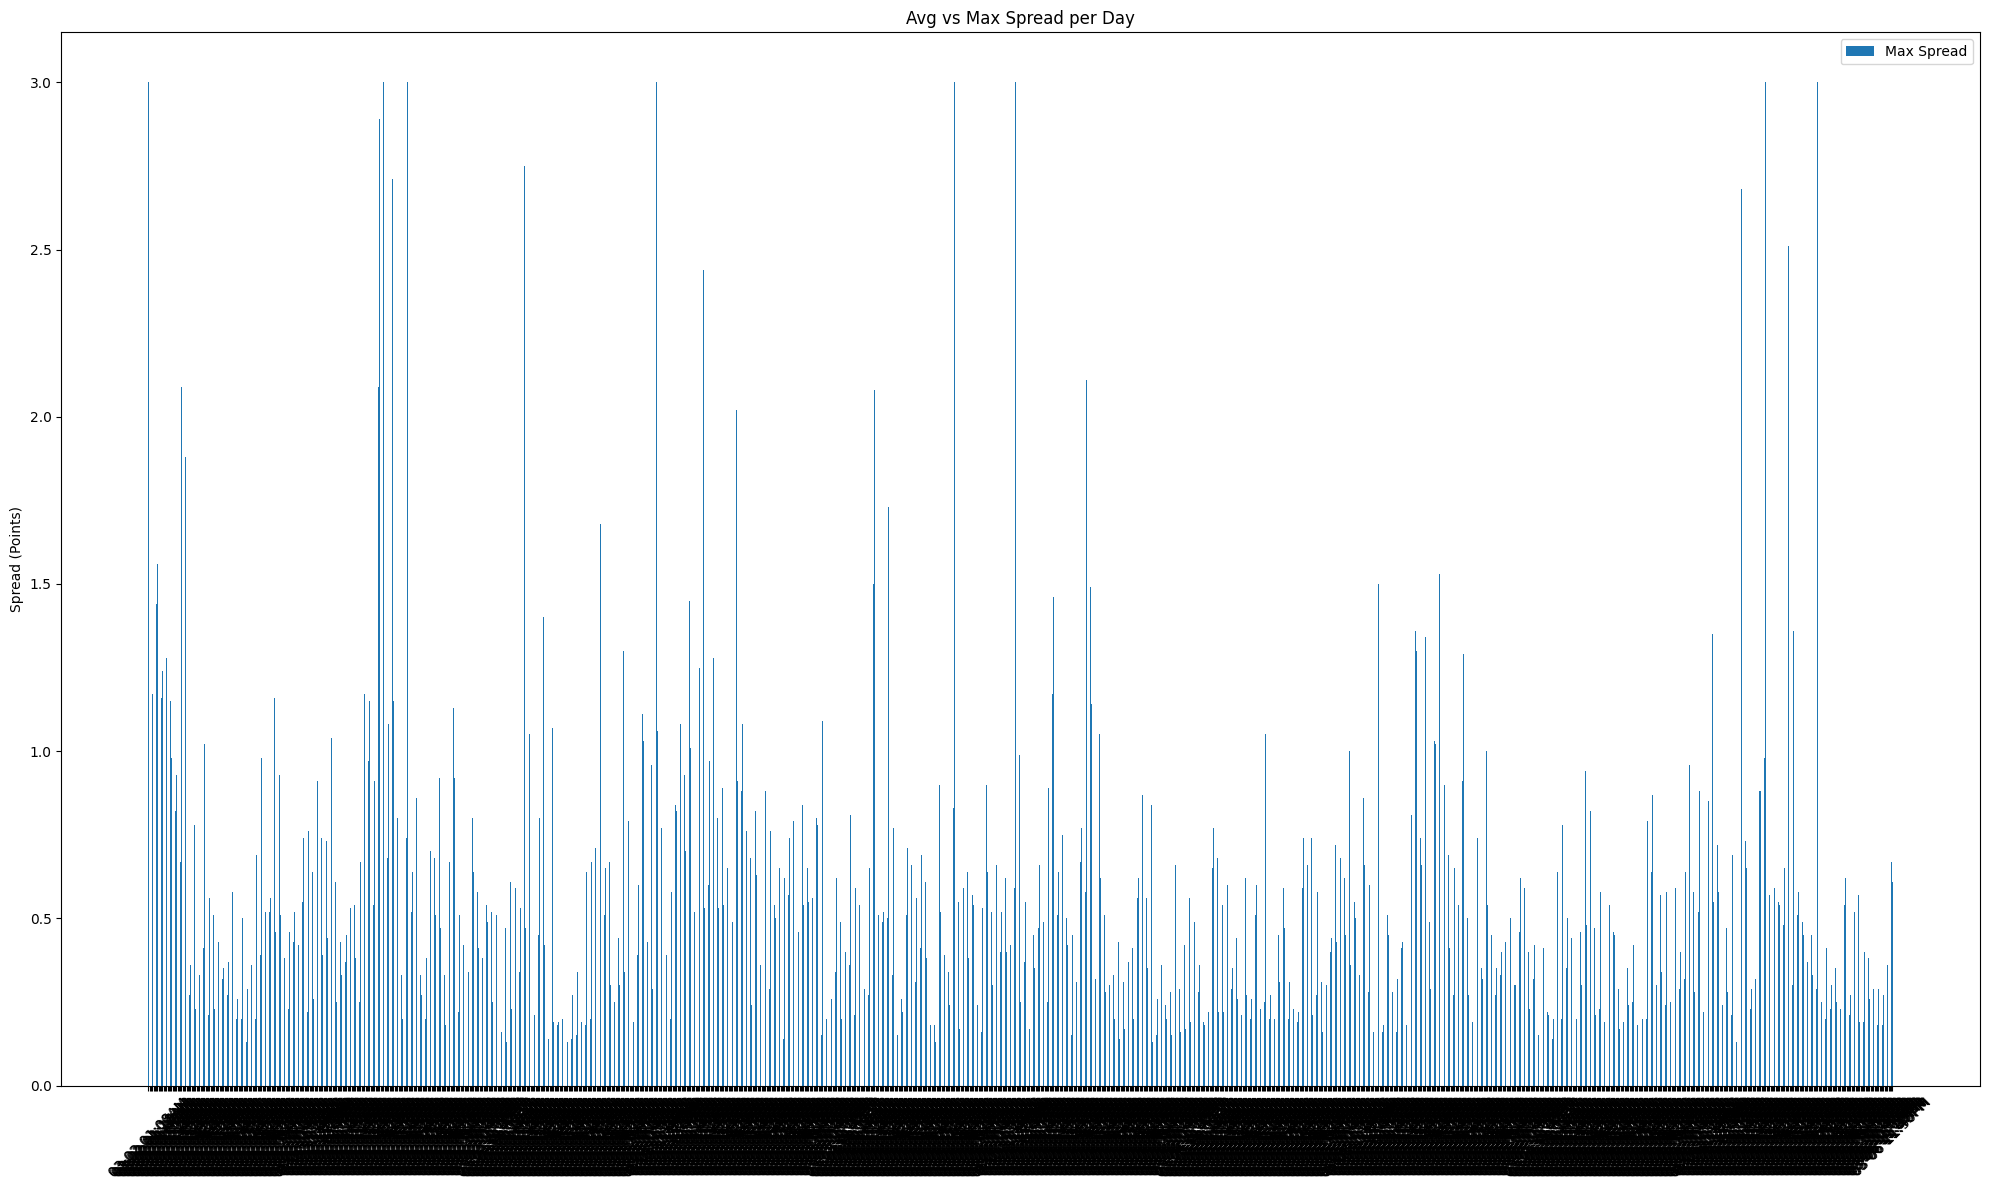

In [165]:
fig, ax = plt.subplots(figsize=(20, 12))
width = 0.35
x = np.arange(len(high_spread))
# Plotting bars
# rects1 = ax.bar(x - width/2, high_spread['mean'], width, label='Avg Spread')
rects2 = ax.bar(x + width/2, high_spread['max'], width, label='Max Spread')

# Adding labels
ax.set_ylabel('Spread (Points)')
ax.set_title('Avg vs Max Spread per Day')
ax.set_xticks(x)
ax.set_xticklabels(high_spread.index.strftime('%m-%d %I:%M%p'), rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [166]:
mt5.shutdown()

True